# 02_reproduce_main_results

Dieses Notebook reproduziert die zentralen Ergebnisse der Meerjungfrauenmärchen-Studie mit den bereitgestellten bereinigten Datensätzen.

Im Mittelpunkt stehen:

- Beschreibung der finalen Stichprobe
- Bildung der Qualitätsmaße
- Hypothesentests H1 bis H4
- zentrale deskriptive Ergebnisse

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

## 1. Bereinigte Datensätze laden

In [19]:
# Für Colab/Drive:
# from google.colab import drive
# drive.mount('/content/drive')

base_dir = Path("") #Pfad eingeben
data_dir = base_dir / "data" / "processed"

# Lokal alternativ:
# base_dir = Path(".")
# data_dir = base_dir / "data" / "processed"

df_master = pd.read_excel(data_dir / "master_clean_renamed.xlsx")
ratings_long = pd.read_excel(data_dir / "ratings_long.xlsx")
compare_long = pd.read_excel(data_dir / "compare_long.xlsx")
estimation_long = pd.read_excel(data_dir / "estimation_long.xlsx")

print(df_master.shape, ratings_long.shape, compare_long.shape, estimation_long.shape)

(138, 610) (10585, 10) (2592, 9) (552, 9)


## 2. Stichprobe beschreiben

In [20]:
age_map = {
    "18-24 Jahre": 21,
    "25-34 Jahre": 29.5,
    "35-44 Jahre": 39.5,
    "45-54 Jahre": 49.5,
    "55-64 Jahre": 59.5,
    "65 Jahre oder älter": 70
}

reading_map = {
    "Nie": 0,
    "Seltener als einmal im Monat (z.B. nur im Urlaub)": 1,
    "Etwa einmal pro Monat": 2,
    "Mehrmals pro Monat": 3,
    "Etwa einmal pro Woche": 4,
    "Mehrmals pro Woche": 5,
    "Täglich": 6
}

edu_order = [
    "Kein Schulabschluss",
    "Hauptschulabschluss",
    "Realschulabschluss / Mittlere Reife",
    "Fachhochschulreife / Abitur",
    "Bachelor",
    "Master",
    "Promotion",
    "Anderes:"
]

df_master["age_num"] = df_master["age"].map(age_map)
df_master["reading_num"] = df_master["reading_frequency_raw"].map(reading_map)

df_master["native_bin"] = np.where(
    df_master["native_language"].astype(str).str.strip().str.lower() == "deutsch",
    "Deutsch",
    "andere"
)

# Bildungsabschluss als geordnete Kategorie
df_master["education"] = (
    df_master["education"]
    .astype(str)
    .str.strip()
    .replace({"Sonstiges": "Anderes:"})  # falls in manchen Datensätzen "Sonstiges" steht
)
df_master["education"] = pd.Categorical(
    df_master["education"],
    categories=edu_order,
    ordered=True
)

print("N gesamt:", len(df_master))

print("\nGruppenverteilung:")
print(df_master["group"].value_counts())

print("\nAlter nach Gruppe:")
print(df_master.groupby("group")["age_num"].agg(["mean", "std", "count"]))
a = df_master.loc[df_master["group"] == "A", "age_num"].dropna()
b = df_master.loc[df_master["group"] == "B", "age_num"].dropna()
t_age, p_age = stats.ttest_ind(a, b, equal_var=False)
print(f"Welch-t Alter: t = {t_age:.3f}, p = {p_age:.3f}")

print("\nLesehäufigkeit nach Gruppe:")
print(df_master.groupby("group")["reading_num"].agg(["mean", "std", "count"]))
a = df_master.loc[df_master["group"] == "A", "reading_num"].dropna()
b = df_master.loc[df_master["group"] == "B", "reading_num"].dropna()
t_read, p_read = stats.ttest_ind(a, b, equal_var=False)
print(f"Welch-t Lesehäufigkeit: t = {t_read:.3f}, p = {p_read:.3f}")

print("\nGeschlecht nach Gruppe:")
tab_gender = pd.crosstab(df_master["group"], df_master["gender"])
print(tab_gender)
chi2_gender, p_gender, _, _ = stats.chi2_contingency(tab_gender)
print(f"Chi-Quadrat Geschlecht: χ² = {chi2_gender:.3f}, p = {p_gender:.3f}")

print("\nMuttersprache nach Gruppe:")
tab_native = pd.crosstab(df_master["group"], df_master["native_bin"])
print(tab_native)
chi2_native, p_native, _, _ = stats.chi2_contingency(tab_native)
print(f"Chi-Quadrat Muttersprache: χ² = {chi2_native:.3f}, p = {p_native:.3f}")

print("\nBildungsabschluss nach Gruppe:")
tab_edu = pd.crosstab(df_master["group"], df_master["education"], dropna=False)
tab_edu = tab_edu.reindex(columns=edu_order, fill_value=0)
print(tab_edu)
tab_edu_test = tab_edu.loc[:, (tab_edu.sum(axis=0) > 0)]
chi2_edu, p_edu, dof_edu, expected_edu = stats.chi2_contingency(tab_edu_test)

print(f"Chi-Quadrat Bildungsabschluss: χ² = {chi2_edu:.3f}, df = {dof_edu}, p = {p_edu:.3f}")
print("\nART-Rate nach Gruppe:")
print(df_master.groupby("group")["ART_rate"].agg(["mean", "std", "count"]))
a = df_master.loc[df_master["group"] == "A", "ART_rate"].dropna()
b = df_master.loc[df_master["group"] == "B", "ART_rate"].dropna()
t_art, p_art = stats.ttest_ind(a, b, equal_var=False)
print(f"Welch-t ART-Rate: t = {t_art:.3f}, p = {p_art:.3f}")

N gesamt: 138

Gruppenverteilung:
group
B    69
A    69
Name: count, dtype: int64

Alter nach Gruppe:
            mean        std  count
group                             
A      40.057971  15.910026     69
B      38.811594  15.576212     69
Welch-t Alter: t = 0.465, p = 0.643

Lesehäufigkeit nach Gruppe:
           mean       std  count
group                           
A      3.072464  1.950255     69
B      3.333333  1.899432     69
Welch-t Lesehäufigkeit: t = -0.796, p = 0.427

Geschlecht nach Gruppe:
gender  Männlich  Weiblich
group                     
A             24        45
B             23        45
Chi-Quadrat Geschlecht: χ² = 0.000, p = 1.000

Muttersprache nach Gruppe:
native_bin  Deutsch  andere
group                      
A                64       5
B                66       3
Chi-Quadrat Muttersprache: χ² = 0.133, p = 0.716

Bildungsabschluss nach Gruppe:
education  Kein Schulabschluss  Hauptschulabschluss  \
group                                                 
A    

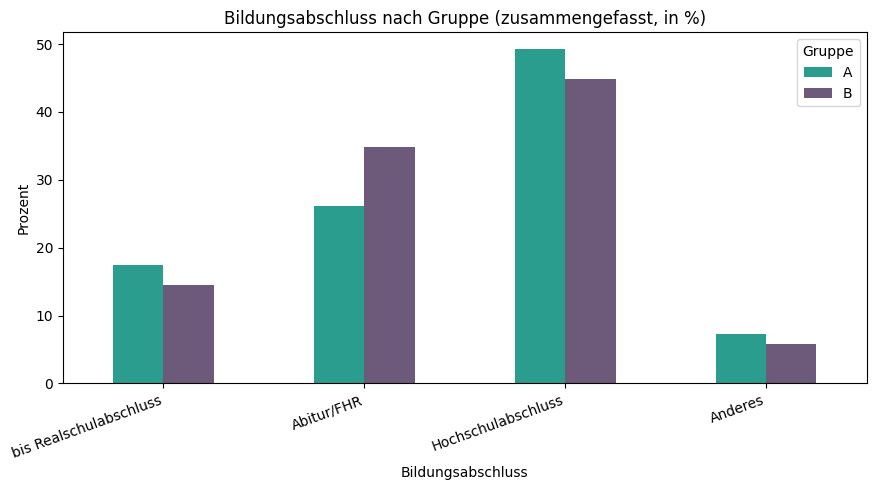

In [21]:
#Grafik zum Gruppenunterschied im Bildungsabschluss
edu_collapsed = {
    "Kein Schulabschluss": "bis Realschulabschluss",
    "Hauptschulabschluss": "bis Realschulabschluss",
    "Realschulabschluss / Mittlere Reife": "bis Realschulabschluss",
    "Fachhochschulreife / Abitur": "Abitur/FHR",
    "Bachelor": "Hochschulabschluss",
    "Master": "Hochschulabschluss",
    "Promotion": "Hochschulabschluss",
    "Anderes:": "Anderes"
}

df_master["education_collapsed"] = df_master["education"].map(edu_collapsed)

order_collapsed = [
    "bis Realschulabschluss",
    "Abitur/FHR",
    "Hochschulabschluss",
    "Anderes"
]

tab_edu_collapsed = pd.crosstab(df_master["group"], df_master["education_collapsed"])
tab_edu_collapsed = tab_edu_collapsed.reindex(columns=order_collapsed, fill_value=0)

tab_edu_collapsed_pct = tab_edu_collapsed.div(tab_edu_collapsed.sum(axis=1), axis=0) * 100

ax = tab_edu_collapsed_pct.T.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#2A9D8F", "#6D597A"]
)

plt.title("Bildungsabschluss nach Gruppe (zusammengefasst, in %)")
plt.xlabel("Bildungsabschluss")
plt.ylabel("Prozent")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Gruppe")
plt.tight_layout()
plt.show()

## 3. Qualitätsmaße bilden

Für die zentrale Qualitätsanalyse werden nur die geschlossenen Einzelitems 1–8 berücksichtigt.

In [22]:
# Items 1-8 filtern

ratings_core = ratings_long[ratings_long["item_no"].between(1, 8)].copy()

print(ratings_core.shape)
print(ratings_core["item_no"].value_counts().sort_index())

(8832, 10)
item_no
1    1104
2    1104
3    1104
4    1104
5    1104
6    1104
7    1104
8    1104
Name: count, dtype: int64


In [23]:
#Dimensionen nach Kienecker + Bedeutung

appetenz_items = [1, 2, 4, 5]
leistung_items = [3, 6]
akzeptanz_items = [7]
bedeutung_items = [8]

dim_map = {}
for item in appetenz_items:
    dim_map[item] = "Appetenz"
for item in leistung_items:
    dim_map[item] = "Leistung"
for item in akzeptanz_items:
    dim_map[item] = "Akzeptanz"
for item in bedeutung_items:
    dim_map[item] = "Bedeutung"

ratings_core["dimension"] = ratings_core["item_no"].map(dim_map)

In [24]:
# Gesamtqualität pro Person x Texttyp

quality_person = (
    ratings_core
    .groupby(["participant_id", "group", "text_type"], as_index=False)["response_num"]
    .mean()
    .rename(columns={"response_num": "QualityIndex"})
)

quality_wide = (
    quality_person
    .pivot(index=["participant_id", "group"], columns="text_type", values="QualityIndex")
    .reset_index()
)

quality_wide["DeltaQuality"] = quality_wide["human"] - quality_wide["ai"]

print(quality_wide.head())

text_type  participant_id group       ai    human  DeltaQuality
0                       4     B  5.71875  5.00000      -0.71875
1                       8     A  4.84375  3.78125      -1.06250
2                       9     A  4.21875  3.37500      -0.84375
3                      13     A  4.75000  4.90625       0.15625
4                      14     B  3.87500  5.87500       2.00000


## 4. Deskriptive Qualitätsbewertungen + Voraussetzungsprüfung

In [25]:
import numpy as np
from scipy import stats

def ci95_lower(series):
    x = series.dropna()
    n = len(x)
    if n < 2:
        return np.nan
    m = x.mean()
    se = stats.sem(x)
    h = se * stats.t.ppf(0.975, df=n-1)
    return m - h

def ci95_upper(series):
    x = series.dropna()
    n = len(x)
    if n < 2:
        return np.nan
    m = x.mean()
    se = stats.sem(x)
    h = se * stats.t.ppf(0.975, df=n-1)
    return m + h

print("Gesamtmittelwerte:")
print(
    quality_person.groupby("text_type")["QualityIndex"]
    .agg(
        mean="mean",
        std="std",
        count="count",
        ci95_lower=ci95_lower,
        ci95_upper=ci95_upper
    )
)

print("\nNach Gruppe und Texttyp:")
print(
    quality_person.groupby(["group", "text_type"])["QualityIndex"]
    .agg(
        mean="mean",
        std="std",
        count="count",
        ci95_lower=ci95_lower,
        ci95_upper=ci95_upper
    )
)

Gesamtmittelwerte:
               mean       std  count  ci95_lower  ci95_upper
text_type                                                   
ai         4.822464  0.908869    138    4.669474    4.975454
human      4.898324  0.805540    138    4.762728    5.033921

Nach Gruppe und Texttyp:
                     mean       std  count  ci95_lower  ci95_upper
group text_type                                                   
A     ai         5.152174  0.775973     69    4.965765    5.338583
      human      4.668478  0.753271     69    4.487523    4.849434
B     ai         4.492754  0.917325     69    4.272388    4.713119
      human      5.128170  0.795426     69    4.937088    5.319252


Normalverteilung DeltaQuality
Gruppe A: W = 0.980, p = 0.338
Gruppe B: W = 0.984, p = 0.503

Varianzhomogenität DeltaQuality
Levene: W = 2.016, p = 0.158

Ausreißerprüfung DeltaQuality (|z| > 3)
Gruppe A: 0 Ausreißer
Gruppe B: 0 Ausreißer


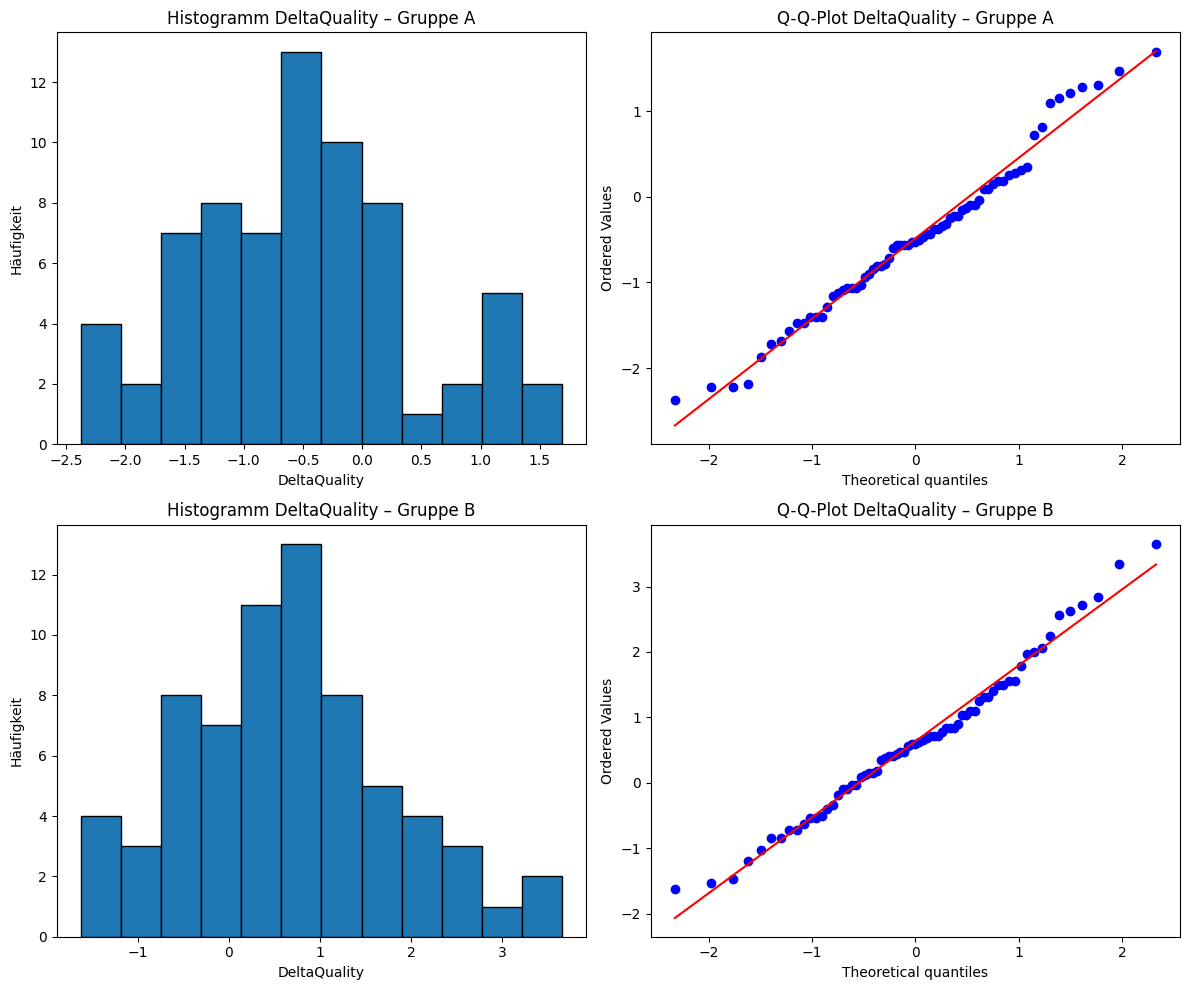

Normalverteilung der Differenzwerte in Gruppe B (H2)
W = 0.984, p = 0.503


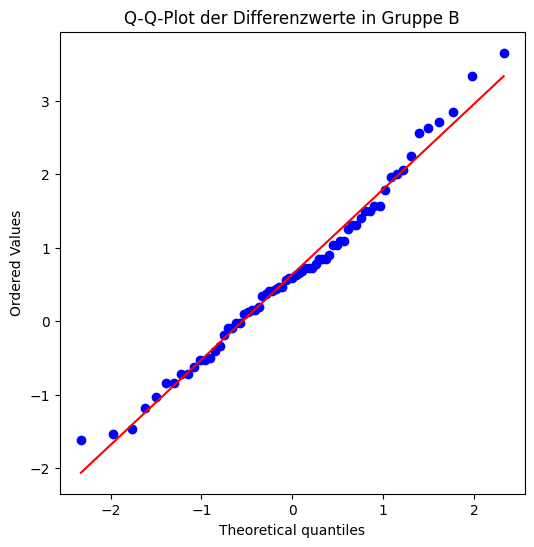

In [26]:

import scipy.stats as stats
import matplotlib.pyplot as plt


# VORAUSSETZUNGSPRÜFUNG H1 / H2
# DeltaQuality = human - ai


delta_A = quality_wide.loc[quality_wide["group"] == "A", "DeltaQuality"].dropna()
delta_B = quality_wide.loc[quality_wide["group"] == "B", "DeltaQuality"].dropna()


# 1) Shapiro-Wilk-Test

shapiro_A = stats.shapiro(delta_A)
shapiro_B = stats.shapiro(delta_B)

print("Normalverteilung DeltaQuality")
print(f"Gruppe A: W = {shapiro_A.statistic:.3f}, p = {shapiro_A.pvalue:.3f}")
print(f"Gruppe B: W = {shapiro_B.statistic:.3f}, p = {shapiro_B.pvalue:.3f}")


# 2) Levene-Test

levene_res = stats.levene(delta_A, delta_B)

print("\nVarianzhomogenität DeltaQuality")
print(f"Levene: W = {levene_res.statistic:.3f}, p = {levene_res.pvalue:.3f}")


# 3) Ausreißer über z-Werte

z_A = np.abs(stats.zscore(delta_A, nan_policy="omit"))
z_B = np.abs(stats.zscore(delta_B, nan_policy="omit"))

outliers_A = delta_A[z_A > 3]
outliers_B = delta_B[z_B > 3]

print("\nAusreißerprüfung DeltaQuality (|z| > 3)")
print(f"Gruppe A: {len(outliers_A)} Ausreißer")
print(f"Gruppe B: {len(outliers_B)} Ausreißer")

if len(outliers_A) > 0:
    print("Werte Gruppe A:")
    print(outliers_A)

if len(outliers_B) > 0:
    print("Werte Gruppe B:")
    print(outliers_B)


# 4) Grafische Prüfung
# Histogramm + Q-Q-Plot

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histogramm A
axes[0, 0].hist(delta_A, bins=12, edgecolor="black")
axes[0, 0].set_title("Histogramm DeltaQuality – Gruppe A")
axes[0, 0].set_xlabel("DeltaQuality")
axes[0, 0].set_ylabel("Häufigkeit")

# QQ-Plot A
stats.probplot(delta_A, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q-Plot DeltaQuality – Gruppe A")

# Histogramm B
axes[1, 0].hist(delta_B, bins=12, edgecolor="black")
axes[1, 0].set_title("Histogramm DeltaQuality – Gruppe B")
axes[1, 0].set_xlabel("DeltaQuality")
axes[1, 0].set_ylabel("Häufigkeit")

# QQ-Plot B
stats.probplot(delta_B, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q-Plot DeltaQuality – Gruppe B")

plt.tight_layout()
plt.show()


# ZUSATZ FÜR H2:
# Normalverteilung der Differenzwerte in Gruppe B


delta_B = quality_wide.loc[quality_wide["group"] == "B", "DeltaQuality"].dropna()

shapiro_h2 = stats.shapiro(delta_B)

print("Normalverteilung der Differenzwerte in Gruppe B (H2)")
print(f"W = {shapiro_h2.statistic:.3f}, p = {shapiro_h2.pvalue:.3f}")

plt.figure(figsize=(6, 6))
stats.probplot(delta_B, dist="norm", plot=plt)
plt.title("Q-Q-Plot der Differenzwerte in Gruppe B")
plt.show()

Normalverteilung Accuracy
Gruppe A: W = 0.911, p = 0.000
Gruppe B: W = 0.826, p = 0.000

Varianzhomogenität Accuracy
Levene: W = 0.060, p = 0.807


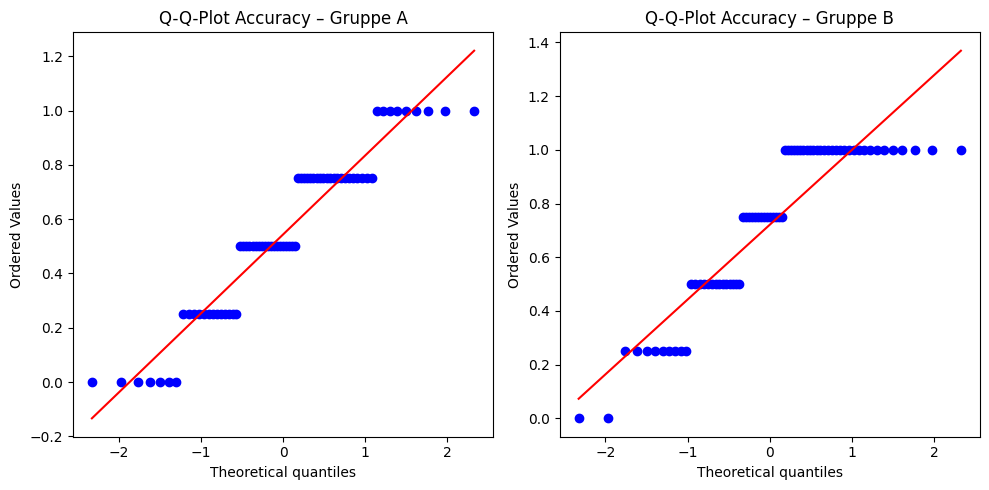

In [27]:
accuracy_person = (
    estimation_long
    .groupby(["participant_id", "group"], as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "Accuracy"})
)

# VORAUSSETZUNGSPRÜFUNG H4
# Accuracy pro Person


acc_A = accuracy_person.loc[accuracy_person["group"] == "A", "Accuracy"].dropna()
acc_B = accuracy_person.loc[accuracy_person["group"] == "B", "Accuracy"].dropna()


# 1) Shapiro-Wilk-Test

shapiro_acc_A = stats.shapiro(acc_A)
shapiro_acc_B = stats.shapiro(acc_B)

print("Normalverteilung Accuracy")
print(f"Gruppe A: W = {shapiro_acc_A.statistic:.3f}, p = {shapiro_acc_A.pvalue:.3f}")
print(f"Gruppe B: W = {shapiro_acc_B.statistic:.3f}, p = {shapiro_acc_B.pvalue:.3f}")

# 2) Levene-Test

levene_acc = stats.levene(acc_A, acc_B)

print("\nVarianzhomogenität Accuracy")
print(f"Levene: W = {levene_acc.statistic:.3f}, p = {levene_acc.pvalue:.3f}")

# 3) Q-Q-Plots

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

stats.probplot(acc_A, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q-Plot Accuracy – Gruppe A")

stats.probplot(acc_B, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q-Plot Accuracy – Gruppe B")

plt.tight_layout()
plt.show()

## 5. H1

Geprüft wird, ob der Unterschied zwischen Human- und AI-Bewertungen in Gruppe B größer ist als in Gruppe A.

In [28]:
delta_A = quality_wide.loc[quality_wide["group"] == "A", "DeltaQuality"].dropna()
delta_B = quality_wide.loc[quality_wide["group"] == "B", "DeltaQuality"].dropna()

t_h1, p_h1 = stats.ttest_ind(delta_A, delta_B, equal_var=False)

mean_A = delta_A.mean()
sd_A = delta_A.std(ddof=1)

mean_B = delta_B.mean()
sd_B = delta_B.std(ddof=1)

# Cohen's d für unabhängige Gruppen
n1, n2 = len(delta_A), len(delta_B)
pooled_sd = np.sqrt(((n1 - 1) * sd_A**2 + (n2 - 1) * sd_B**2) / (n1 + n2 - 2))
d_h1 = (mean_B - mean_A) / pooled_sd

# 95%-KI der Mittelwertsdifferenz nach Welch
mean_diff = mean_B - mean_A
se_diff = np.sqrt((sd_A**2 / n1) + (sd_B**2 / n2))

df_welch = ((sd_A**2 / n1 + sd_B**2 / n2) ** 2) / (
    ((sd_A**2 / n1) ** 2) / (n1 - 1) +
    ((sd_B**2 / n2) ** 2) / (n2 - 1)
)

t_crit = stats.t.ppf(0.975, df=df_welch)
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

# 95%-KI für Cohen's d (Näherung)
se_d = np.sqrt((n1 + n2) / (n1 * n2) + (d_h1**2 / (2 * (n1 + n2 - 2))))
d_ci_low = d_h1 - 1.96 * se_d
d_ci_high = d_h1 + 1.96 * se_d

print("H1")
print("Gruppe A: M =", mean_A, "SD =", sd_A)
print("Gruppe B: M =", mean_B, "SD =", sd_B)
print("Mittelwertsdifferenz (B - A) =", mean_diff)
print(f"95%-KI der Differenz = [{ci_low:.3f}, {ci_high:.3f}]")
print("Welch-t =", t_h1)
print("p =", p_h1)
print(f"Cohen's d = {d_h1:.2f}")
print(f"95%-KI für Cohen's d = [{d_ci_low:.2f}, {d_ci_high:.2f}]")

H1
Gruppe A: M = -0.483695652173913 SD = 0.9288449855132831
Gruppe B: M = 0.6354166666666666 SD = 1.1456773512369236
Mittelwertsdifferenz (B - A) = 1.1191123188405796
95%-KI der Differenz = [0.768, 1.470]
Welch-t = -6.302831357026117
p = 4.157863819771763e-09
Cohen's d = 1.07
95%-KI für Cohen's d = [0.72, 1.43]


In [29]:
# Lineares Mixed-Effects_Modell

import statsmodels.formula.api as smf

# Sicherstellen, dass die Variablen passend codiert sind
df_lmm = quality_person.copy()

df_lmm["group"] = df_lmm["group"].astype("category")
df_lmm["text_type"] = df_lmm["text_type"].astype("category")
df_lmm["participant_id"] = df_lmm["participant_id"].astype("category")

# Referenzkategorien setzen, falls du A und ai als Referenz willst
df_lmm["group"] = df_lmm["group"].cat.reorder_categories(["A", "B"])
df_lmm["text_type"] = df_lmm["text_type"].cat.reorder_categories(["ai", "human"])

# Random Intercept für Personen
lmm_h1 = smf.mixedlm(
    "QualityIndex ~ group * text_type",
    data=df_lmm,
    groups=df_lmm["participant_id"]
).fit()

print(lmm_h1.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     QualityIndex
No. Observations:       276         Method:                 REML        
No. Groups:             138         Scale:                  0.5438      
Min. group size:        2           Log-Likelihood:         -335.9330   
Max. group size:        2           Converged:              Yes         
Mean group size:        2.0                                             
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      5.152    0.098 52.642 0.000  4.960  5.344
group[T.B]                    -0.659    0.138 -4.764 0.000 -0.931 -0.388
text_type[T.human]            -0.484    0.126 -3.853 0.000 -0.730 -0.238
group[T.B]:text_type[T.human]  1.119    0.178  6.303 0.000  0.771  1.

In [30]:
# Analyse pro Textpaar

def to_numeric_likert(series):
    return pd.to_numeric(series.astype(str).str.extract(r"(\d+)")[0], errors="coerce")

pick = lambda p: [c for c in df_master.columns if any(c.startswith(f"{p}{i}.") for i in range(1, 9))]

# Gruppe A nutzt A-Spalten, Gruppe B nutzt B-Spalten
df_master["p1_human"] = df_master[pick("A11")].apply(to_numeric_likert).mean(axis=1)
df_master["p1_ai"]    = df_master[pick("A12")].apply(to_numeric_likert).mean(axis=1)
df_master.loc[df_master["group"] == "B", "p1_human"] = df_master.loc[df_master["group"] == "B", pick("B11")].apply(to_numeric_likert).mean(axis=1)
df_master.loc[df_master["group"] == "B", "p1_ai"]    = df_master.loc[df_master["group"] == "B", pick("B12")].apply(to_numeric_likert).mean(axis=1)

df_master["p2_ai"]    = df_master[pick("A21")].apply(to_numeric_likert).mean(axis=1)
df_master["p2_human"] = df_master[pick("A22")].apply(to_numeric_likert).mean(axis=1)
df_master.loc[df_master["group"] == "B", "p2_ai"]    = df_master.loc[df_master["group"] == "B", pick("B21")].apply(to_numeric_likert).mean(axis=1)
df_master.loc[df_master["group"] == "B", "p2_human"] = df_master.loc[df_master["group"] == "B", pick("B22")].apply(to_numeric_likert).mean(axis=1)

df_master["p3_ai"]    = df_master[pick("A31")].apply(to_numeric_likert).mean(axis=1)
df_master["p3_human"] = df_master[pick("A32")].apply(to_numeric_likert).mean(axis=1)
df_master.loc[df_master["group"] == "B", "p3_ai"]    = df_master.loc[df_master["group"] == "B", pick("B31")].apply(to_numeric_likert).mean(axis=1)
df_master.loc[df_master["group"] == "B", "p3_human"] = df_master.loc[df_master["group"] == "B", pick("B32")].apply(to_numeric_likert).mean(axis=1)

df_master["p4_human"] = df_master[pick("A41")].apply(to_numeric_likert).mean(axis=1)
df_master["p4_ai"]    = df_master[pick("A42")].apply(to_numeric_likert).mean(axis=1)
df_master.loc[df_master["group"] == "B", "p4_human"] = df_master.loc[df_master["group"] == "B", pick("B41")].apply(to_numeric_likert).mean(axis=1)
df_master.loc[df_master["group"] == "B", "p4_ai"]    = df_master.loc[df_master["group"] == "B", pick("B42")].apply(to_numeric_likert).mean(axis=1)

for p in [1, 2, 3, 4]:
    df_master[f"delta_p{p}"] = df_master[f"p{p}_human"] - df_master[f"p{p}_ai"]
    a = df_master.loc[df_master["group"] == "A", f"delta_p{p}"].dropna()
    b = df_master.loc[df_master["group"] == "B", f"delta_p{p}"].dropna()
    t, pval = stats.ttest_ind(a, b, equal_var=False)

    print(f"Textpaar {p}")
    print(f"Gruppe A: M = {a.mean():.3f}, SD = {a.std(ddof=1):.3f}")
    print(f"Gruppe B: M = {b.mean():.3f}, SD = {b.std(ddof=1):.3f}")
    print(f"Welch-t = {t:.3f}, p = {pval:.3f}\n")

Textpaar 1
Gruppe A: M = -0.188, SD = 1.127
Gruppe B: M = 1.091, SD = 1.536
Welch-t = -5.575, p = 0.000

Textpaar 2
Gruppe A: M = -0.332, SD = 1.433
Gruppe B: M = 0.908, SD = 1.443
Welch-t = -5.061, p = 0.000

Textpaar 3
Gruppe A: M = -0.553, SD = 1.332
Gruppe B: M = 0.527, SD = 1.377
Welch-t = -4.681, p = 0.000

Textpaar 4
Gruppe A: M = -0.862, SD = 1.523
Gruppe B: M = 0.016, SD = 1.514
Welch-t = -3.399, p = 0.001



## 6. H2

Geprüft wird, ob in Gruppe B menschliche Texte höher bewertet werden als KI-Texte.

In [31]:
quality_B = quality_wide[quality_wide["group"] == "B"].copy()

t_h2, p_h2 = stats.ttest_rel(quality_B["human"], quality_B["ai"])
diff_B = quality_B["human"] - quality_B["ai"]

m_human = quality_B["human"].mean()
m_ai = quality_B["ai"].mean()
m_diff = diff_B.mean()
sd_diff = diff_B.std(ddof=1)
n = len(diff_B)

# 95%-KI der Mittelwertsdifferenz
se_diff = sd_diff / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
ci_low = m_diff - t_crit * se_diff
ci_high = m_diff + t_crit * se_diff

# Cohen's dz + approximatives 95%-KI
dz_h2 = m_diff / sd_diff
se_dz = np.sqrt((1 / n) + (dz_h2**2 / (2 * n)))
dz_ci_low = dz_h2 - 1.96 * se_dz
dz_ci_high = dz_h2 + 1.96 * se_dz

# Wilcoxon
w_h2, p_w_h2 = stats.wilcoxon(quality_B["human"], quality_B["ai"])

print("H2")
print("Mensch B: M =", m_human)
print("KI B: M =", m_ai)
print("M(H-AI) =", m_diff)
print("paired t =", t_h2)
print("p =", p_h2)
print(f"95%-KI Mittelwertsdifferenz = [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Cohen's dz = {dz_h2:.2f}")
print(f"95%-KI dz = [{dz_ci_low:.2f}, {dz_ci_high:.2f}]")
print("Wilcoxon W =", w_h2)
print("Wilcoxon p =", p_w_h2)

# --- getrennt nach Textpaaren in Gruppe B ---
pick = lambda p: [c for c in df_master.columns if any(c.startswith(f"{p}{i}.") for i in range(1, 9))]
df_B = df_master[df_master["group"] == "B"].copy()

pairs = {
    1: (
        df_B[pick("B11")].apply(to_numeric_likert).mean(axis=1),
        df_B[pick("B12")].apply(to_numeric_likert).mean(axis=1),
    ),
    2: (
        df_B[pick("B22")].apply(to_numeric_likert).mean(axis=1),
        df_B[pick("B21")].apply(to_numeric_likert).mean(axis=1),
    ),
    3: (
        df_B[pick("B32")].apply(to_numeric_likert).mean(axis=1),
        df_B[pick("B31")].apply(to_numeric_likert).mean(axis=1),
    ),
    4: (
        df_B[pick("B41")].apply(to_numeric_likert).mean(axis=1),
        df_B[pick("B42")].apply(to_numeric_likert).mean(axis=1),
    ),
}

print("\nH2 nach Textpaar")
for i, (human_i, ai_i) in pairs.items():
    diff_i = human_i - ai_i
    t_i, p_i = stats.ttest_rel(human_i, ai_i)
    dz_i = diff_i.mean() / diff_i.std(ddof=1)
    print(
        f"Textpaar {i}: "
        f"M(H-AI) = {diff_i.mean():.2f}, "
        f"t = {t_i:.2f}, "
        f"p = {p_i:.3f}, "
        f"dz = {dz_i:.2f}"
    )

H2
Mensch B: M = 5.128170289855072
KI B: M = 4.492753623188406
M(H-AI) = 0.6354166666666666
paired t = 4.607027659690268
p = 1.8478959989811296e-05
95%-KI Mittelwertsdifferenz = [0.36, 0.91]
Cohen's dz = 0.55
95%-KI dz = [0.30, 0.81]
Wilcoxon W = 531.5
Wilcoxon p = 5.2919116540711386e-05

H2 nach Textpaar
Textpaar 1: M(H-AI) = 1.09, t = 5.90, p = 0.000, dz = 0.71
Textpaar 2: M(H-AI) = 0.91, t = 5.23, p = 0.000, dz = 0.63
Textpaar 3: M(H-AI) = 0.53, t = 3.18, p = 0.002, dz = 0.38
Textpaar 4: M(H-AI) = 0.02, t = 0.09, p = 0.929, dz = 0.01


## 7. H3

Geprüft wird, ob die Gesamt-Erkennungsrate signifikant über 50 % liegt.

In [32]:
n_total = len(estimation_long)
n_correct = int(estimation_long["correct"].sum())
accuracy_total = estimation_long["correct"].mean()
sd_total = estimation_long["correct"].std(ddof=1)

# Binomialtest
binom_res = stats.binomtest(n_correct, n_total, p=0.5, alternative="greater")
ci_total = binom_res.proportion_ci(confidence_level=0.95)

# Chi² gegen 50/50
observed = np.array([n_correct, n_total - n_correct])
expected = np.array([n_total / 2, n_total / 2])
chi2_h3 = ((observed - expected) ** 2 / expected).sum()
p_chi2_h3 = 1 - stats.chi2.cdf(chi2_h3, df=1)

# Cramér's V
cramers_v = np.sqrt(chi2_h3 / n_total)

print("H3")
print("n_total =", n_total)
print("n_correct =", n_correct)
print("Accuracy =", accuracy_total)
print(f"95%-KI Accuracy = [{ci_total.low:.3f}, {ci_total.high:.3f}]")
print("SD =", sd_total)
print("Binomialtest p =", binom_res.pvalue)
print("Chi² =", chi2_h3)
print("Chi² p =", p_chi2_h3)
print("Cramér's V =", cramers_v)

print("\nAccuracy nach Texttyp:")
for tt, sub in estimation_long.groupby("true_type"):
    n_tt = len(sub)
    k_tt = int(sub["correct"].sum())
    acc_tt = sub["correct"].mean()
    ci_tt = stats.binomtest(k_tt, n_tt).proportion_ci(confidence_level=0.95)
    print(
        f"{tt}: n = {n_tt}, Accuracy = {acc_tt:.3f}, "
        f"95%-KI [{ci_tt.low:.3f}, {ci_tt.high:.3f}]"
    )

# logistisches Mixed-Effects-Modell mit Random Intercepts für Teilnehmende
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

glmm_h3 = BinomialBayesMixedGLM.from_formula(
    "correct ~ 1",
    {"participant": "0 + C(participant_id)"},
    estimation_long
).fit_vb()

logit_b = glmm_h3.fe_mean[0]
logit_se = glmm_h3.fe_sd[0]

p_hat = 1 / (1 + np.exp(-logit_b))
p_low = 1 / (1 + np.exp(-(logit_b - 1.96 * logit_se)))
p_high = 1 / (1 + np.exp(-(logit_b + 1.96 * logit_se)))

print("\nLogistisches Mixed-Effects-Modell")
print("logit Intercept =", logit_b)
print("SE =", logit_se)
print(f"geschätzte Wahrscheinlichkeit p = {p_hat:.3f}")
print(f"approx. 95%-Intervall = [{p_low:.3f}, {p_high:.3f}]")

H3
n_total = 552
n_correct = 349
Accuracy = 0.6322463768115942
95%-KI Accuracy = [0.597, 1.000]
SD = 0.4826312004703246
Binomialtest p = 2.699292575639901e-10
Chi² = 38.61594202898551
Chi² p = 5.159576099700303e-10
Cramér's V = 0.2644927536231884

Accuracy nach Texttyp:
ai: n = 282, Accuracy = 0.585, 95%-KI [0.525, 0.643]
human: n = 270, Accuracy = 0.681, 95%-KI [0.622, 0.737]

Logistisches Mixed-Effects-Modell
logit Intercept = 0.6912650092085193
SE = 0.09866383826468042
geschätzte Wahrscheinlichkeit p = 0.666
approx. 95%-Intervall = [0.622, 0.708]


## 8. H4

Geprüft wird, ob die individuelle Erkennungsleistung in Gruppe B höher ist als in Gruppe A.

In [33]:
accuracy_person = (
    estimation_long
    .groupby(["participant_id", "group"], as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "Accuracy"})
)

acc_A = accuracy_person.loc[accuracy_person["group"] == "A", "Accuracy"].dropna()
acc_B = accuracy_person.loc[accuracy_person["group"] == "B", "Accuracy"].dropna()

t_h4, p_h4 = stats.ttest_ind(acc_A, acc_B, equal_var=False)
u_h4, p_u_h4 = stats.mannwhitneyu(acc_A, acc_B, alternative="two-sided")

mean_A = acc_A.mean()
sd_A = acc_A.std(ddof=1)
mean_B = acc_B.mean()
sd_B = acc_B.std(ddof=1)

pooled_sd_h4 = np.sqrt(((len(acc_A)-1)*sd_A**2 + (len(acc_B)-1)*sd_B**2) / (len(acc_A)+len(acc_B)-2))
d_h4 = (mean_B - mean_A) / pooled_sd_h4

# 95%-KI der Mittelwertsdifferenz (B - A) nach Welch
n1, n2 = len(acc_A), len(acc_B)
mean_diff = mean_B - mean_A
se_diff = np.sqrt((sd_A**2 / n1) + (sd_B**2 / n2))
df_welch = ((sd_A**2 / n1 + sd_B**2 / n2) ** 2) / (
    ((sd_A**2 / n1) ** 2) / (n1 - 1) +
    ((sd_B**2 / n2) ** 2) / (n2 - 1)
)
t_crit = stats.t.ppf(0.975, df=df_welch)
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

print("H4")
print("Gruppe A Accuracy: M =", mean_A, "SD =", sd_A)
print("Gruppe B Accuracy: M =", mean_B, "SD =", sd_B)
print("Mittelwertsdifferenz (B - A) =", mean_diff)
print(f"95%-KI der Differenz = [{ci_low:.2f}, {ci_high:.2f}]")
print("Welch-t =", t_h4)
print("p =", p_h4)
print("Mann-Whitney U =", u_h4)
print("Mann-Whitney p =", p_u_h4)
print("Cohen's d =", d_h4)

print("\nAccuracy nach Gruppe x Texttyp:")
print(estimation_long.groupby(["group", "true_type"])["correct"].mean())

# logistische Regression auf Einzelebene
import statsmodels.formula.api as smf

logit_h4 = smf.logit("correct ~ C(group)", data=estimation_long).fit(disp=False)

beta = logit_h4.params["C(group)[T.B]"]
p_beta = logit_h4.pvalues["C(group)[T.B]"]
or_h4 = np.exp(beta)
ci_beta_low, ci_beta_high = logit_h4.conf_int().loc["C(group)[T.B]"]
or_low, or_high = np.exp(ci_beta_low), np.exp(ci_beta_high)

print("\nLogistische Regression H4")
print("β =", beta)
print("p =", p_beta)
print("Odds Ratio =", or_h4)
print(f"95%-KI OR = [{or_low:.2f}, {or_high:.2f}]")

H4
Gruppe A Accuracy: M = 0.5434782608695652 SD = 0.2969097014986034
Gruppe B Accuracy: M = 0.7210144927536232 SD = 0.2986988692525527
Mittelwertsdifferenz (B - A) = 0.17753623188405798
95%-KI der Differenz = [0.08, 0.28]
Welch-t = -3.501576695027042
p = 0.0006261176423088175
Mann-Whitney U = 1591.5
Mann-Whitney p = 0.0005455216260015178
Cohen's d = 0.596148005918881

Accuracy nach Gruppe x Texttyp:
group  true_type
A      ai           0.473684
       human        0.608392
B      ai           0.684564
       human        0.763780
Name: correct, dtype: float64

Logistische Regression H4
β = 0.7751460157260308
p = 1.7696826869811253e-05
Odds Ratio = 2.170909090909091
95%-KI OR = [1.52, 3.09]


## 10. Ergebniszusammenfassung

Mit den bereitgestellten bereinigten Datensätzen lassen sich die zentralen Ergebnisse der Arbeit reproduzieren:

- finale Stichprobe: N = 138
- KI-Texte werden in Gruppe A höher bewertet als menschliche Texte
- menschliche Texte werden in Gruppe B höher bewertet als KI-Texte
- H1 und H2 werden unterstützt
- die Gesamt-Accuracy liegt bei ca. 63,2 %
- die Erkennungsleistung in Gruppe B ist deutlich höher als in Gruppe A